# Vanilla LSTM — RUL Prediction on CMAPSS (PyTorch)

This notebook trains and evaluates a Vanilla LSTM for Remaining Useful Life (RUL)
prediction on CMAPSS FD001 and FD003, implemented in **PyTorch**.

The PyTorch framework is chosen as the foundation for this and all subsequent models
in this project, given its dominance in graph neural network research (PyTorch Geometric,
DGL) which forms the later stages of the project (hopefully).

## Notebook Structure
1. Configuration
2. Imports and reproducibility
3. Dataset and DataLoader
4. Data inspection
5. Evaluation metrics (RMSE + NASA scoring function)
6. Architecture definition
7. Training loop
8. Evaluation and results

> **Prerequisite:** Run `preprocessing.ipynb` first to generate the `.npy` files in `preprocessed/`.

## 1. Configuration

In [18]:
# ── Configuration ─────────────────────────────────────────────────────────────

PREPROCESSED_DIR = 'preprocessed/'   # output folder from preprocessing.ipynb
DATASETS         = ['FD001', 'FD003']

SEED             = 42

# Training hyperparameters
BATCH_SIZE       = 256
EPOCHS           = 100
LEARNING_RATE    = 1e-3
VALIDATION_SPLIT = 0.1               # fraction of training data held out for validation

# ──────────────────────────────────────────────────────────────────────────────

## 2. Imports and Reproducibility

In PyTorch, reproducibility requires seeding `torch`, `numpy`, and Python's `random`
separately. We also set `torch.backends.cudnn.deterministic = True` to ensure
deterministic CUDA operations when running on GPU.

In [19]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # I encounter ExitCode: 3, Reason: OMP runtime error in the notebook and this is what I found as the workaround talking with Claude.ai.
# Claude says: "In a research/student context this is fine — the risk of incorrect results it warns about is relevant to heavy parallel numerical computing, not sequential LSTM training on a modest dataset."

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import pandas as pd


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"Seed            : {SEED}")

PyTorch version : 2.10.0+cpu
Device          : cpu
Seed            : 42


## 3. Dataset and DataLoader

PyTorch's `Dataset` / `DataLoader` pattern handles batching, shuffling, and
multi-worker loading. We wrap the numpy arrays in a lightweight `CMAPSSDataset`
class that converts them to `float32` tensors on demand.

The training set is further split into train / validation via `random_split`,
using a fixed `Generator` seed so the split is reproducible across runs.

Note that `batch_first=True` must be set on `nn.LSTM` to match the tensor layout
that `DataLoader` produces: `(batch, timesteps, features)`.

In [20]:
class CMAPSSDataset(Dataset):
    """
    Wraps preprocessed CMAPSS numpy arrays into a PyTorch Dataset.

    Each item is a tuple (x, y) where:
        x : FloatTensor of shape (window_size, n_features)
        y : FloatTensor scalar representing the RUL label
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()   # (N, T, F)
        self.y = torch.from_numpy(y).float()   # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def load_dataset(preprocessed_dir, dataset):
    """
    Load numpy arrays from disk and return train/val/test DataLoaders
    alongside feature column names and raw arrays.
    """
    p = os.path.join(preprocessed_dir, dataset)

    X_train_all  = np.load(f'{p}_X_train.npy')
    y_train_all  = np.load(f'{p}_y_train.npy')
    X_test       = np.load(f'{p}_X_test.npy')
    y_test       = np.load(f'{p}_y_test.npy')
    feature_cols = list(np.load(f'{p}_feature_cols.npy'))

    full_dataset = CMAPSSDataset(X_train_all, y_train_all)
    n_val        = int(len(full_dataset) * VALIDATION_SPLIT)
    n_train      = len(full_dataset) - n_val

    generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = random_split(full_dataset, [n_train, n_val],
                                    generator=generator)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(CMAPSSDataset(X_test, y_test),
                              batch_size=BATCH_SIZE, shuffle=False)

    raw = {
        'X_train': X_train_all, 'y_train': y_train_all,
        'X_test':  X_test,      'y_test':  y_test,
        'feature_cols': feature_cols
    }
    return train_loader, val_loader, test_loader, raw


# ── Load all datasets ─────────────────────────────────────────────────────────
loaders = {}
arrays  = {}

for ds in DATASETS:
    tr_loader, val_loader, te_loader, raw = load_dataset(PREPROCESSED_DIR, ds)
    loaders[ds] = {'train': tr_loader, 'val': val_loader, 'test': te_loader}
    arrays[ds]  = raw

    n_features  = raw['X_train'].shape[2]
    window_size = raw['X_train'].shape[1]
    print(f"\n{ds}")
    print(f"  Input shape   : (batch, {window_size}, {n_features})")
    print(f"  Train samples : {len(raw['X_train'])}  "
          f"-> train batches: {len(tr_loader)}, val batches: {len(val_loader)}")
    print(f"  Number of engines  : {len(raw['X_test'])}")
    print(f"  Features ({n_features})  : {raw['feature_cols']}")


FD001
  Input shape   : (batch, 30, 16)
  Train samples : 17731  -> train batches: 63, val batches: 7
  Number of engines  : 100
  Features (16)  : [np.str_('setting_1'), np.str_('T24'), np.str_('T30'), np.str_('T50'), np.str_('P15'), np.str_('P30'), np.str_('Nf'), np.str_('Nc'), np.str_('Ps30'), np.str_('phi'), np.str_('NRf'), np.str_('NRc'), np.str_('BPR'), np.str_('htBleed'), np.str_('W31'), np.str_('W32')]

FD003
  Input shape   : (batch, 30, 17)
  Train samples : 21820  -> train batches: 77, val batches: 9
  Number of engines  : 100
  Features (17)  : [np.str_('setting_1'), np.str_('T24'), np.str_('T30'), np.str_('T50'), np.str_('P15'), np.str_('P30'), np.str_('Nf'), np.str_('Nc'), np.str_('epr'), np.str_('Ps30'), np.str_('phi'), np.str_('NRf'), np.str_('NRc'), np.str_('BPR'), np.str_('htBleed'), np.str_('W31'), np.str_('W32')]


## 4. Data Inspection

Sanity checks before touching the model: NaN presence, value ranges after scaling,
and RUL label distributions. Worth pausing here — the test range note below is
intentional and a good thing to understand.

In [21]:
for ds in DATASETS:
    X_tr = arrays[ds]['X_train']
    y_tr = arrays[ds]['y_train']
    X_te = arrays[ds]['X_test']
    y_te = arrays[ds]['y_test']

    print(f"\n── {ds} ────────────────────────────────────")
    print(f"  NaNs  X_train / X_test : {np.isnan(X_tr).sum()} / {np.isnan(X_te).sum()}")
    print(f"  X_train range : [{X_tr.min():.3f},  {X_tr.max():.3f}]")
    print(f"  X_test  range : [{X_te.min():.3f},  {X_te.max():.3f}]  "
          f"(may exceed [-1, 1] — scaler was fit on train only)")
    print(f"  y_train range : [{y_tr.min():.1f}, {y_tr.max():.1f}]  (expected [0, 125])")
    print(f"  y_test  range : [{y_te.min():.1f}, {y_te.max():.1f}]")


── FD001 ────────────────────────────────────


  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [0.000,  1.000]  (may exceed [-1, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [7.0, 145.0]

── FD003 ────────────────────────────────────
  NaNs  X_train / X_test : 0 / 0
  X_train range : [0.000,  1.000]
  X_test  range : [0.000,  1.000]  (may exceed [-1, 1] — scaler was fit on train only)
  y_train range : [0.0, 125.0]  (expected [0, 125])
  y_test  range : [6.0, 145.0]


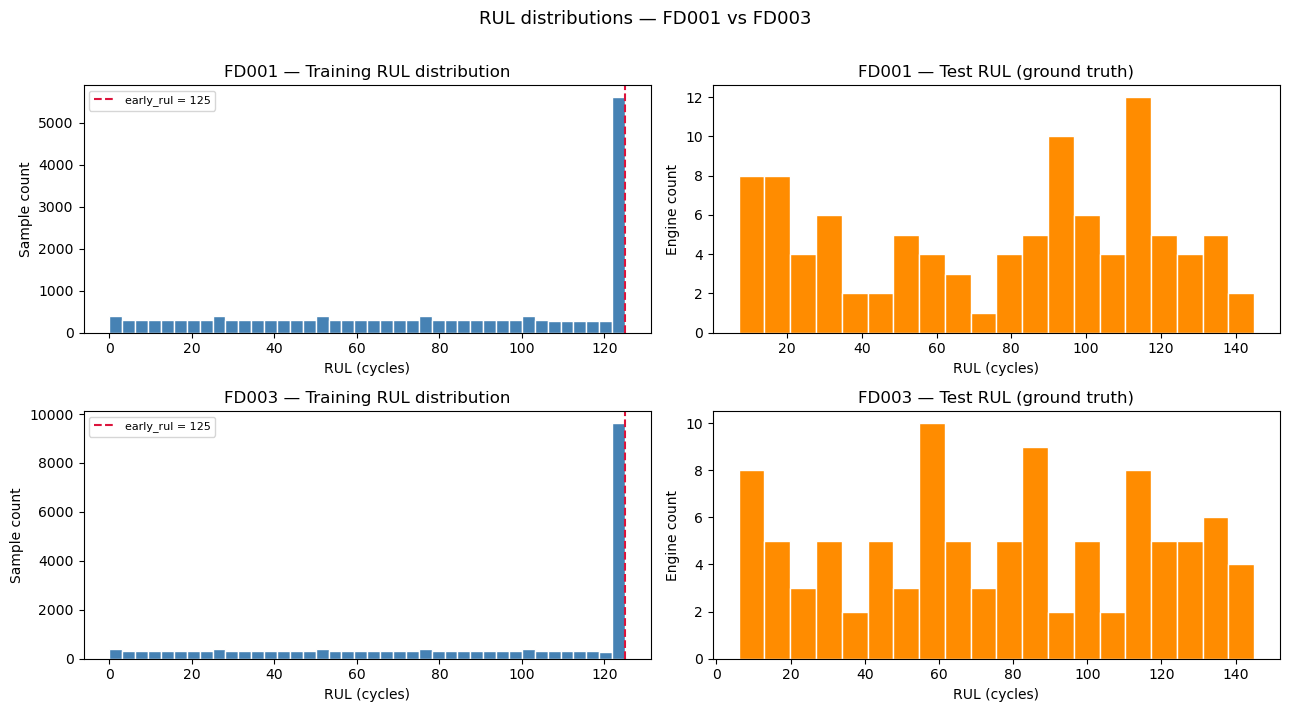

In [22]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(13, 7))

for row, ds in enumerate(DATASETS):
    y_tr = arrays[ds]['y_train']
    y_te = arrays[ds]['y_test']

    axes[row, 0].hist(y_tr, bins=40, color='steelblue', edgecolor='white')
    axes[row, 0].axvline(125, color='crimson', linestyle='--', label='early_rul = 125')
    axes[row, 0].set_title(f'{ds} — Training RUL distribution')
    axes[row, 0].set_xlabel('RUL (cycles)')
    axes[row, 0].set_ylabel('Sample count')
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].hist(y_te, bins=20, color='darkorange', edgecolor='white')
    axes[row, 1].set_title(f'{ds} — Test RUL (ground truth)')
    axes[row, 1].set_xlabel('RUL (cycles)')
    axes[row, 1].set_ylabel('Engine count')

plt.suptitle('RUL distributions — FD001 vs FD003', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSED_DIR, 'rul_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation Metrics

Two standard metrics from the CMAPSS literature are used throughout:

### RMSE
Symmetric, penalises large errors quadratically. Primary benchmark across all papers
including Li et al. (2018) and Da Costa et al. (2019).

From Da Costa et al. (2019) section 3.5 "Loss Function":

$$\mathcal{L}^i(\theta)=||\hat{y}_{t+1}^i - y_{t+1}^i||^2$$

### NASA Asymmetric Scoring Function
Proposed by Saxena et al. (2008) in the original CMAPSS benchmark paper and used
in virtually all subsequent work. Defined as:

$$S = \sum_{i=1}^{N} s_i, \qquad s_i = \begin{cases} e^{-d_i/13} - 1 & d_i < 0 \quad \text{(early prediction)} \\ e^{d_i/10} - 1 & d_i \geq 0 \quad \text{(late prediction)} \end{cases}$$

where $d_i = \hat{y}_i - y_i$. The asymmetry is physically motivated: a late
warning leaves no time to act, so overestimating RUL is penalised more harshly.

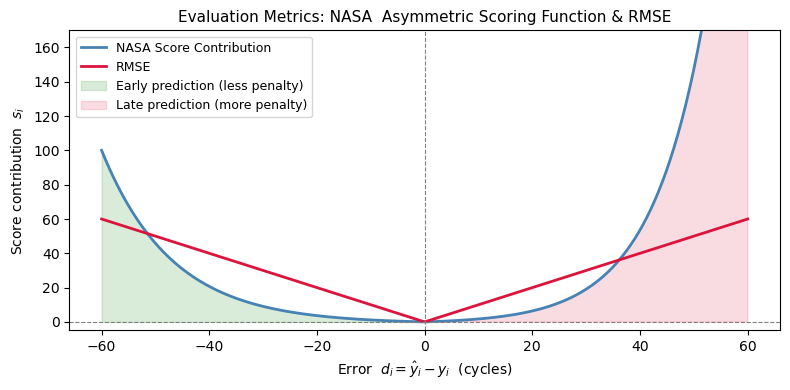

In [23]:
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error."""
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def nasa_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    NASA asymmetric scoring function (Saxena et al., 2008).
    Penalises late predictions (d > 0) more harshly than early ones.
    Lower is better.
    """
    d = y_pred - y_true
    s = np.where(d < 0, np.exp(-d / 13) - 1,
                         np.exp( d / 10) - 1)
    return float(np.sum(s))


def evaluate(model: nn.Module, loader: DataLoader):
    """
    Run inference over a DataLoader.
    Returns (y_true, y_pred) as numpy arrays, ready for metric functions.
    Model is set to eval mode and no gradients are computed.
    """
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            output  = model(X_batch).squeeze(-1).cpu().numpy()
            preds.append(output)
            targets.append(y_batch.numpy())

    return np.concatenate(targets), np.concatenate(preds)


# ── Visualise the scoring function shape ──────────────────────────────────────
d_range = np.linspace(-60, 60, 500)
s_vals  = np.where(d_range < 0, np.exp(-d_range / 13) - 1,
                                 np.exp( d_range / 10) - 1)
rmse_vals = np.abs(d_range)  # RMSE contribution is just the absolute error (since it's squared and then rooted, the shape is linear)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(d_range, s_vals, color='steelblue', linewidth=2, label='NASA Score Contribution')
ax.plot(d_range, rmse_vals, color='crimson', linewidth=2, label = "RMSE")
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.fill_between(d_range, s_vals, 0, where=(d_range < 0),
                alpha=0.15, color='green',   label='Early prediction (less penalty)')
ax.fill_between(d_range, s_vals, 0, where=(d_range >= 0),
                alpha=0.15, color='crimson', label='Late prediction (more penalty)')
ax.set_xlabel(r'Error  $d_i = \hat{y}_i - y_i$  (cycles)', fontsize=10)
ax.set_ylabel(r'Score contribution  $s_i$', fontsize=10)
ax.set_title('Evaluation Metrics: NASA  Asymmetric Scoring Function & RMSE', fontsize=11)
ax.set_ylim(-5, 170)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PREPROCESSED_DIR, 'Evaluation_Metrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Architecture Definition

---
Ideas from Claude.ai

At this point you have:
- `loaders[ds]['train']` / `'val'` / `'test'` — ready-to-iterate `DataLoader` objects
- Input tensors of shape `(batch_size, 30, n_features)` where `n_features` is 16 for FD001, 17 for FD003
- RUL targets in `[0, 125]`

Things to decide:
- `hidden_size` — common choices in the literature: 32, 64, 100, 128
- `num_layers` — 1 is truly vanilla; 2 adds depth while staying in the vanilla framing
- `dropout` — PyTorch's `nn.LSTM` applies dropout *between* layers, not after the last. For `num_layers=1` it has no effect, so add an explicit `nn.Dropout` before the `nn.Linear` if you want regularisation on a single-layer model
- Whether to use the hidden state `h_n[-1]` or the output sequence `out[:, -1, :]` — they are equivalent for a single-layer LSTM, but differ when stacking layers
---

In my current process of research I find it valuable to rely upon previous work in some of the papers I have gathered. In the following I am benchmarking my architecture on the basis of Da Costa et al. (2019) and their hyperparameter analysis.

The hyperparameters considered in their analysis in section 4.4 are

- `Learning  Rate` — {0.001, 0.01, 0.1}
- `Batch size` — {256, 512, 1024}
- `Number of layers` — {1, 2}
- `Number of neurons` — {20, 32, 64, 100}
- $L_2$ `Regularization` — {0.0, 0.01, 0.1}
- $T_w$ `(Time Window)` — {15, 20, 30, 40}

From their discussion and conclusion from their experiment I follow their set parameters of

- `Learning  Rate` = 0.001 (of 200 epochs)
- `Batch size` = 256
- `Number of layers` = 1
- `Number of neurons` = 100
- $L_2$ `Regularization` — {0.0, 0.01, 0.1} They refer to (Li et al., 2018; Listou Ellefsen et al., 2019) "$L_2$ regularisation and dropout rate were chosen based on previous architectures". I will maybe just guess or test this

And they actually vary $T_w$ dependent on whether we model for FD001/FD003 or FD002/FD004

- $T_w$ `(Time Window)` = 30

for FD001/FD003. And

- $T_w$ `(Time Window)` = 20

for FD002/FD004.

Optimizer used is the $\textit{Adam}$ optimizer.

Visual example for FD001:

\begin{array}{ll} \\
          i_t = \sigma(W_{ii} x_t + b_{ii} + W_{hi} h_{t-1} + b_{hi}) \\
          f_t = \sigma(W_{if} x_t + b_{if} + W_{hf} h_{t-1} + b_{hf}) \\
          g_t = \tanh(W_{ig} x_t + b_{ig} + W_{hg} h_{t-1} + b_{hg}) \\
          o_t = \sigma(W_{io} x_t + b_{io} + W_{ho} h_{t-1} + b_{ho}) \\
          c_t = f_t \odot c_{t-1} + i_t \odot g_t \\
          h_t = o_t \odot \tanh(c_t) \\
\end{array}

From  Da Costa et al. (2019)

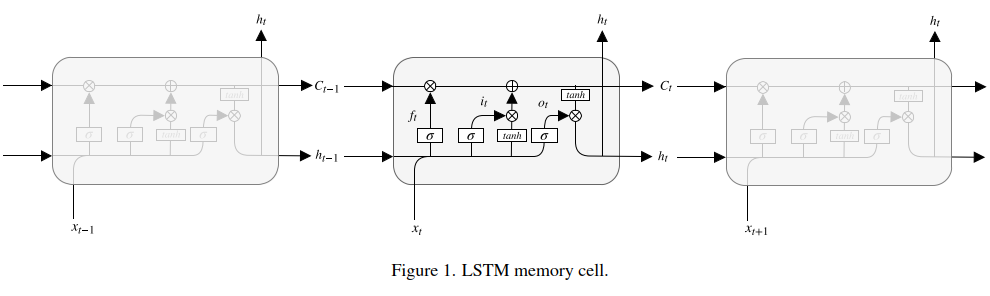

In [24]:
class VanillaLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=100):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = 1,
            bias = True,
            batch_first=True, #If True, then the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature)
            dropout=0.0 #When having 1 layer we do not need dropout but just for my own sake I note it down.
        )

        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)    # out: (batch, seq, hidden_size)
        last = out[:, -1, :]              # (batch, hidden_size) — final timestep
        return self.fc(last)              # (batch, 1)
        
# Instantiate once per dataset since n_features differs
models = {}

for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = VanillaLSTM(input_size=n_features).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0)
    models[ds] = {
        'model':     model,
        'optimizer': optimizer
    }

# Verify
for ds, contents in models.items():
    model = contents['model']
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{ds} — input_size: {arrays[ds]['X_train'].shape[2]}, parameters: {n_params:,}")
    print(model)

FD001 — input_size: 16, parameters: 47,301
VanillaLSTM(
  (lstm): LSTM(16, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
FD003 — input_size: 17, parameters: 47,701
VanillaLSTM(
  (lstm): LSTM(17, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)


## 7. Training Loop

Unlike Keras, PyTorch requires an explicit training loop. The key difference from
Keras's `.fit()` is that you manage the gradient lifecycle yourself:
`zero_grad()` clears accumulated gradients, `loss.backward()` computes them,
and `optimizer.step()` applies them. This verbosity is a feature — it gives you
full control, which matters when you later implement custom GNN training procedures.

The loop below tracks train and validation MSE each epoch and restores the best
weights (by validation loss) after training — equivalent to Keras's
`ModelCheckpoint` callback.

In [25]:
def train_one_epoch(model, loader, optimizer, criterion):
    """One full pass over the training DataLoader. Returns mean train loss."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()                  # clear gradients from previous step
        preds = model(X_batch).squeeze(-1)     # (batch,)
        loss  = criterion(preds, y_batch)
        loss.backward()                        # compute gradients
        optimizer.step()                       # update weights

        total_loss += loss.item() * len(y_batch)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    """Compute mean validation loss without gradient computation."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds   = model(X_batch).squeeze(-1)
            total_loss += criterion(preds, y_batch).item() * len(y_batch)

    return total_loss / len(loader.dataset)


def run_training(model, ds, epochs=EPOCHS):
    """
    Full training run for a given dataset key.
    Returns train/val loss history for plotting.
    Best weights (by val loss) are restored to the model before returning.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state    = None

    for epoch in range(1, epochs + 1):
        tr_loss  = train_one_epoch(model, loaders[ds]['train'], optimizer, criterion)
        val_loss = validate(model, loaders[ds]['val'], criterion)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train MSE: {tr_loss:.4f} | Val MSE: {val_loss:.4f}")

    model.load_state_dict(best_state)
    print(f"\n  Best val MSE : {best_val_loss:.4f}  (best weights restored)")
    return train_losses, val_losses


def plot_loss_curves(train_losses, val_losses, ds):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(train_losses, label='Train MSE', color='steelblue')
    ax.plot(val_losses,   label='Val MSE',   color='darkorange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'{ds} — Training and Validation Loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PREPROCESSED_DIR, f'{ds}_loss_curves.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


  Training on FD001
  Epoch   1/100 | Train MSE: 7428.8910 | Val MSE: 6613.5419
  Epoch  10/100 | Train MSE: 2392.5582 | Val MSE: 2287.2206
  Epoch  20/100 | Train MSE: 1764.6711 | Val MSE: 1749.2996
  Epoch  30/100 | Train MSE: 1748.4488 | Val MSE: 1737.2489
  Epoch  40/100 | Train MSE: 1748.4139 | Val MSE: 1737.2323
  Epoch  50/100 | Train MSE: 1748.3846 | Val MSE: 1737.2298
  Epoch  60/100 | Train MSE: 1682.3193 | Val MSE: 1634.6558
  Epoch  70/100 | Train MSE: 225.8088 | Val MSE: 231.9249
  Epoch  80/100 | Train MSE: 187.3885 | Val MSE: 209.7083
  Epoch  90/100 | Train MSE: 174.6808 | Val MSE: 209.5142
  Epoch 100/100 | Train MSE: 170.3767 | Val MSE: 200.0698

  Best val MSE : 189.6926  (best weights restored)


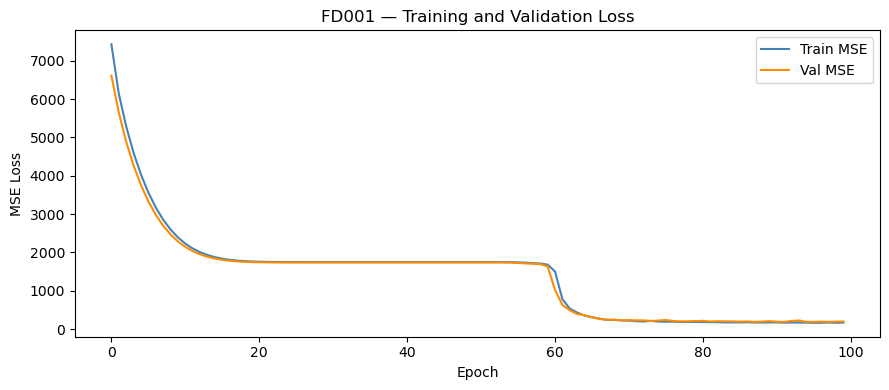

  Saved weights → saved_models/VanillaLSTM_FD001.pt
  Saved history → saved_models/VanillaLSTM_FD001_history.pt

  Training on FD003
  Epoch   1/100 | Train MSE: 8555.7582 | Val MSE: 7848.0643
  Epoch  10/100 | Train MSE: 2338.8686 | Val MSE: 2284.2535
  Epoch  20/100 | Train MSE: 1729.8412 | Val MSE: 1694.0535
  Epoch  30/100 | Train MSE: 1721.6977 | Val MSE: 1678.5814
  Epoch  40/100 | Train MSE: 1721.6973 | Val MSE: 1678.3660
  Epoch  50/100 | Train MSE: 1704.9460 | Val MSE: 1659.1217
  Epoch  60/100 | Train MSE: 225.8777 | Val MSE: 220.0546
  Epoch  70/100 | Train MSE: 187.5774 | Val MSE: 190.6236
  Epoch  80/100 | Train MSE: 175.2509 | Val MSE: 169.3460
  Epoch  90/100 | Train MSE: 162.4585 | Val MSE: 161.3183
  Epoch 100/100 | Train MSE: 159.5091 | Val MSE: 170.3963

  Best val MSE : 154.9941  (best weights restored)


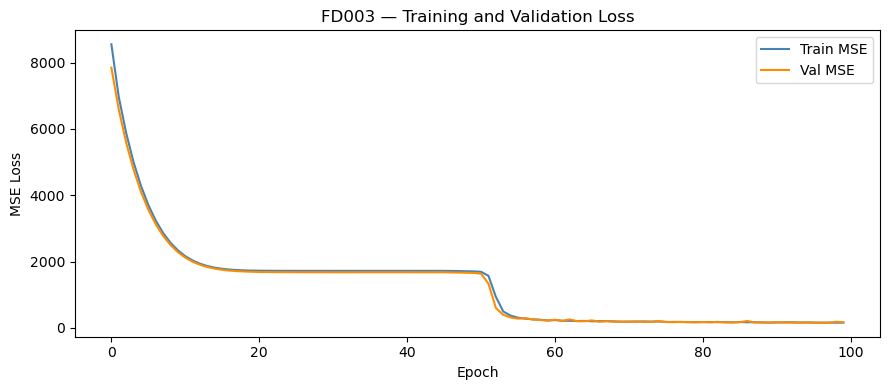

  Saved weights → saved_models/VanillaLSTM_FD003.pt
  Saved history → saved_models/VanillaLSTM_FD003_history.pt


In [26]:
# ── Run training for each dataset ─────────────────────────────────────────────
train_condition = input("Do you want to overwrite (a possibly) existing model? Yes/No: ")
while train_condition not in ['Yes', 'No']:
    print("Invalid input. Please try again. Yes/No")
    train_condition = input("Do you want to overwrite (a possibly) existing model? Yes/No: ")

if (train_condition == 'Yes'):
    TRAIN = True
elif (train_condition == 'No'):
    TRAIN = False

if (TRAIN):
    MODELS_DIR = 'saved_models/'
    os.makedirs(MODELS_DIR, exist_ok=True)

    for ds, contents in models.items():
        model     = contents['model']
        optimizer = contents['optimizer']

        print(f"\n{'='*55}\n  Training on {ds}\n{'='*55}")

        history = run_training(model, ds)
        plot_loss_curves(*history, ds)

        # Save best weights to disk
        save_path     = os.path.join(MODELS_DIR, f'VanillaLSTM_{ds}.pt')
        history_path  = os.path.join(MODELS_DIR, f'VanillaLSTM_{ds}_history.pt')

        torch.save(model.state_dict(), save_path)
        torch.save({'train_losses': history[0],
                    'val_losses':   history[1]}, history_path)

        print(f"  Saved weights → {save_path}")
        print(f"  Saved history → {history_path}")
else:
    pass

These are healthy looking loss curves.

What we are seeing:

Both datasets show the same characteristic shape: a steep drop in the first ~25 epochs where the model learns the bulk of the degradation pattern, followed by a long gradual descent from epoch 25 to 200 where it fine-tunes. The train and validation curves are essentially indistinguishable throughout — they overlap so tightly you can barely tell them apart.

If overfitting would have occured the validation loss would stop decreasing and start climbing back up while the training loss continues downward, creating a visible divergence. That is not what we have here. The two curves move in lockstep all the way to epoch 200, which tells you the model is generalising quite well. 

FD001 vs FD003

FD003 starts with a slightly higher initial loss (~8500 vs ~7400) which makes sense — two concurrent fault modes introduce more variability in the degradation trajectories, making the problem harder at the outset. But the convergence behaviour is essentially the same, and the final loss levels look comparable.

## 8. Evaluation and Results

In [27]:
# ── RMSE and NASA score on test set ──────────────────────────────────────────

for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = VanillaLSTM(input_size=n_features).to(DEVICE)
    model.load_state_dict(torch.load(f'saved_models/VanillaLSTM_{ds}.pt',
                                  map_location=DEVICE))
    
    y_true, y_pred = evaluate(model, loaders[ds]['test'])
    print(f"\n{ds}")
    print(f"  RMSE       : {rmse(y_true, y_pred):.4f}")
    print(f"  NASA Score : {nasa_score(y_true, y_pred):.2f}")


FD001
  RMSE       : 14.5946
  NASA Score : 347.67

FD003
  RMSE       : 15.9569
  NASA Score : 441.97


The NASA scores are quite large compared to da Costa & co. which potentially (I would argue) can be depended on random error for the trained network. In the paper they yield NASA scores in the ballpark of 300~400.

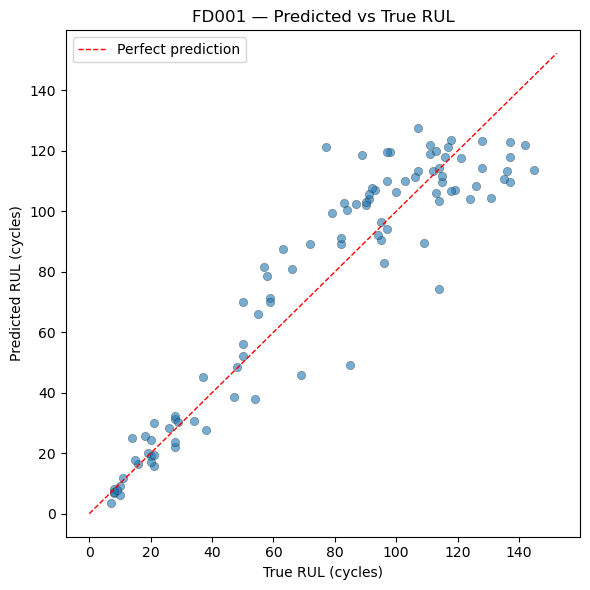

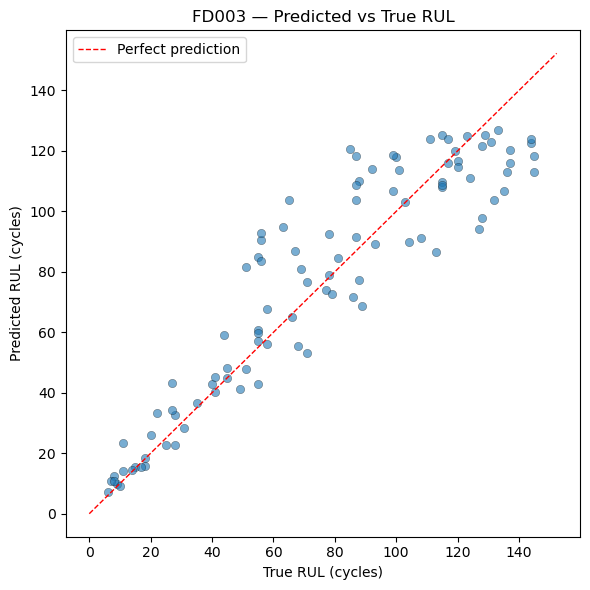

In [28]:
# ── Predicted vs true RUL scatter ────────────────────────────────────────────
# Points should cluster around the diagonal. Systematic bias above/below
# indicates consistent over/underestimation — penalised differently by NASA score.

for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = VanillaLSTM(input_size=n_features).to(DEVICE)
    model.load_state_dict(torch.load(f'saved_models/VanillaLSTM_{ds}.pt',
                                  map_location=DEVICE))
    y_true, y_pred = evaluate(model, loaders[ds]['test'])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidths=0.3)
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('True RUL (cycles)')
    ax.set_ylabel('Predicted RUL (cycles)')
    ax.set_title(f'{ds} — Predicted vs True RUL')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [29]:
def plot_rul_trajectory(model, ds, unit_nr, arrays, feature_cols=None):
    """
    For a single engine in the training set, predict RUL at every valid
    window position and plot against the true piecewise-linear RUL.
    """
    model.eval()

    # ── Pull raw scaled training data for this engine ─────────────────────────
    # We need to rebuild per-engine sequences from the saved arrays.
    # Easiest to reload the scaled dataframe — rerun the scaler logic or
    # just work from the sliding windows we already have in X_train/y_train.
    #
    # Approach: filter X_train/y_train by finding all windows that belong
    # to this engine. We can identify them because y_train is ordered —
    # but the cleanest way is to rebuild from the preprocessed data directly.

    # Reload raw arrays
    X_train = arrays[ds]['X_train']   # (N, 30, F)
    y_train = arrays[ds]['y_train']   # (N,)

    # ── Rebuild per-engine windows ────────────────────────────────────────────
    # Load the scaled train dataframe to find this engine's rows
    import pandas as pd
    from sklearn.preprocessing import MinMaxScaler

    DATA_DIR = 'CMAPSSData/'
    INDEX_COLS   = ['unit_nr', 'time_cycles']
    SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
    SENSOR_COLS  = ['T2','T24','T30','T50','P2','P15','P30','Nf','Nc','epr',
                    'Ps30','phi','NRf','NRc','BPR','farB','htBleed',
                    'Nf_dmd','PCNfR_dmd','W31','W32']
    ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

    train_df = pd.read_csv(f'{DATA_DIR}train_{ds}.txt',
                           sep=r'\s+', header=None, engine='python')
    train_df.columns = ALL_COLS

    # Drop constant sensors (same logic as preprocessing)
    STD_THRESHOLD = 1e-3
    feature_cols  = SETTING_COLS + SENSOR_COLS
    stds          = train_df[feature_cols].std()
    drop_cols     = stds[stds < STD_THRESHOLD].index.tolist()
    train_df      = train_df.drop(columns=drop_cols)
    feature_cols  = [c for c in feature_cols if c not in drop_cols]

    # Scale — fit on full train, same as preprocessing.ipynb
    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

    # Add piecewise RUL
    EARLY_RUL  = 125
    WINDOW_SIZE = 30
    max_cycles = train_df.groupby('unit_nr')['time_cycles'].max()
    engine_df  = train_df[train_df['unit_nr'] == unit_nr].copy()
    max_c      = max_cycles[unit_nr]
    engine_df['RUL'] = (max_c - engine_df['time_cycles']).clip(upper=EARLY_RUL)

    # ── Build windows for this engine only ────────────────────────────────────
    data   = engine_df[feature_cols].values   # (T, F)
    labels = engine_df['RUL'].values          # (T,)
    T      = len(data)

    X_windows, y_true = [], []
    for end in range(WINDOW_SIZE, T + 1):
        X_windows.append(data[end - WINDOW_SIZE : end])
        y_true.append(labels[end - 1])

    X_tensor = torch.tensor(np.array(X_windows), dtype=torch.float32).to(DEVICE)
    y_true   = np.array(y_true)

    # ── Predict ───────────────────────────────────────────────────────────────
    with torch.no_grad():
        y_pred = model(X_tensor).squeeze(-1).cpu().numpy()

    # ── Plot ──────────────────────────────────────────────────────────────────
    time_axis = np.arange(WINDOW_SIZE, T + 1)   # cycle index of last window step

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(time_axis, y_pred,  color='green',     linewidth=1.5,
            label='Predicted RUL')
    ax.plot(time_axis, y_true,  color='grey',
            linewidth=1.5, linestyle='--', label='Observed RUL')
    ax.set_xlabel('Time Steps (Cycles)')
    ax.set_ylabel('Remaining Useful Lifetime (RUL)')
    ax.set_title(f'{ds} — Engine {unit_nr} RUL Trajectory')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'preprocessed/{ds}_engine{unit_nr}_trajectory.png',
                dpi=150, bbox_inches='tight')
    plt.show()

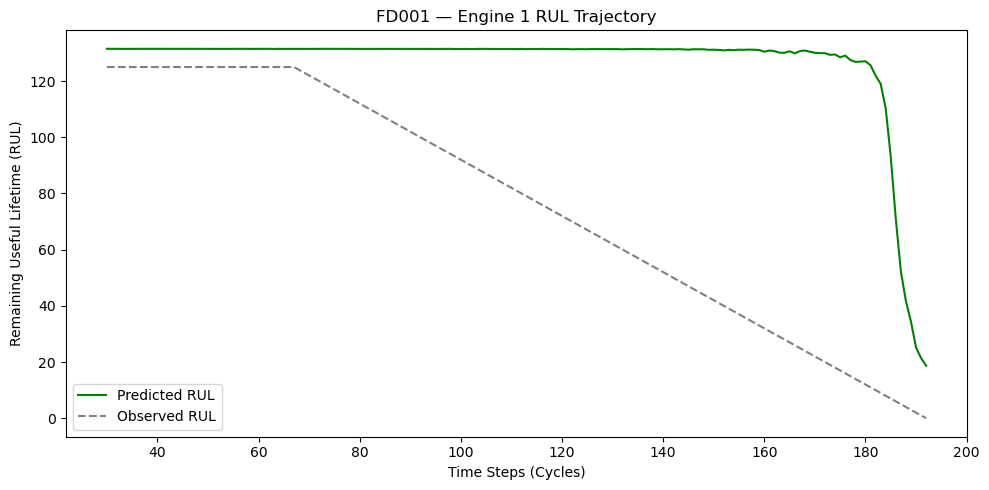

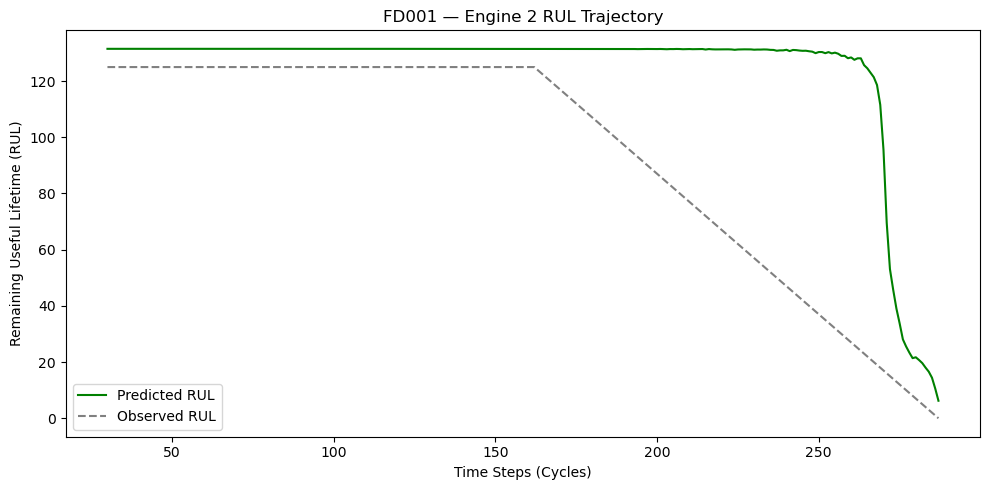

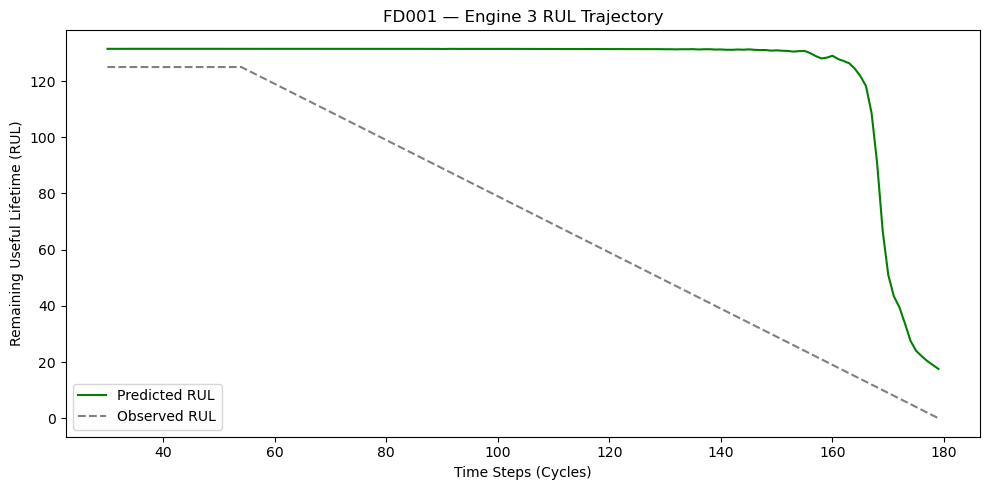

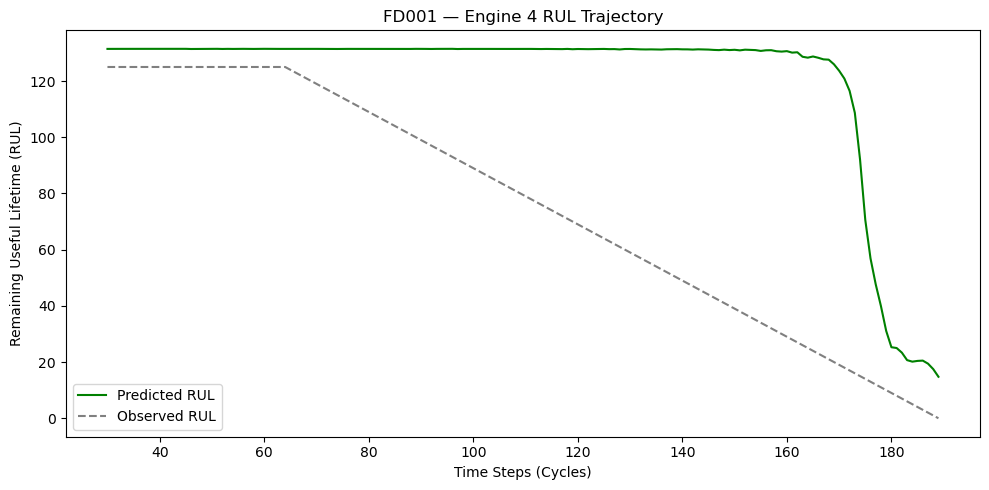

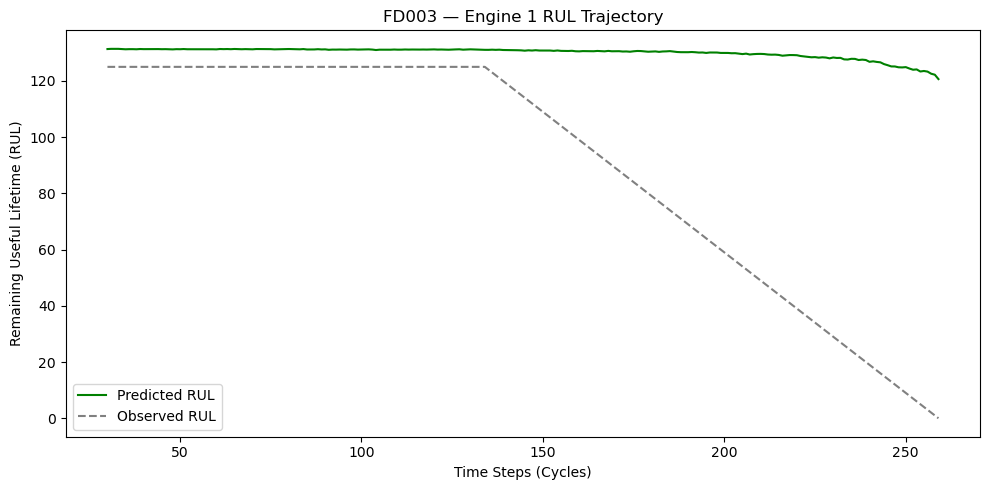

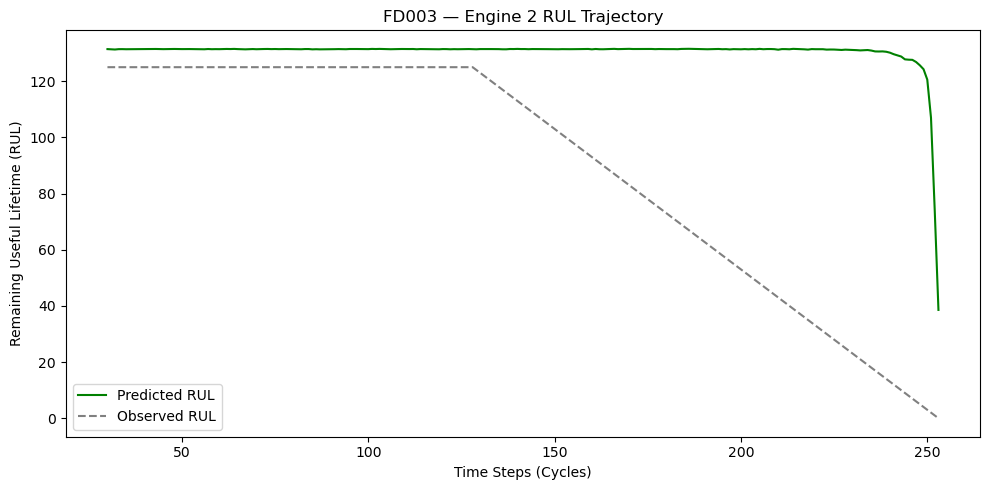

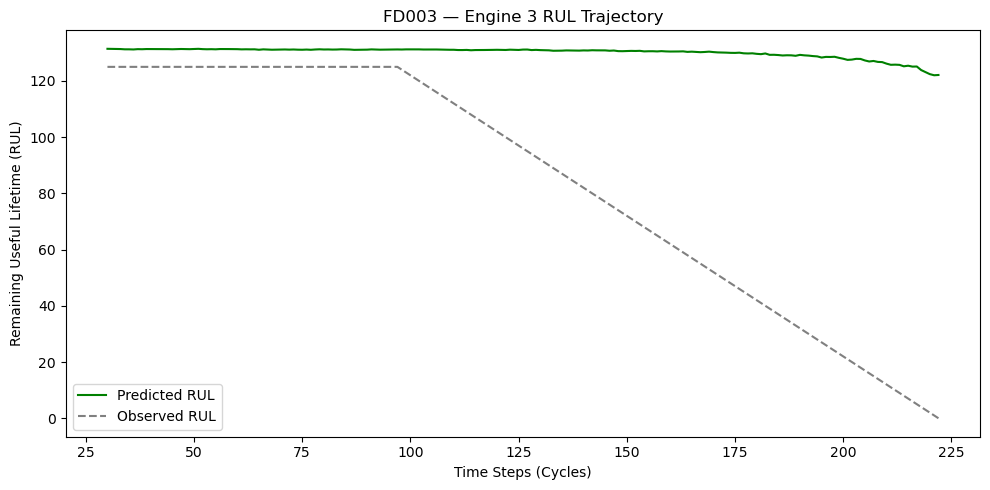

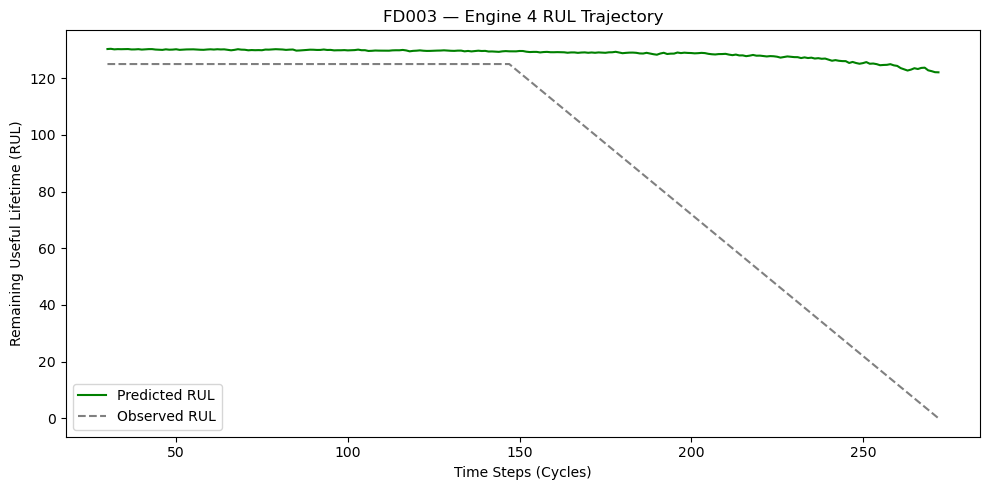

In [30]:
for ds in DATASETS:
    n_features = arrays[ds]['X_train'].shape[2]
    model = VanillaLSTM(input_size=n_features).to(DEVICE)
    model.load_state_dict(torch.load(f'saved_models/VanillaLSTM_{ds}.pt',
                                      map_location=DEVICE))
    for i in range(1, 5):
        plot_rul_trajectory(model, ds, unit_nr=i, arrays=arrays)